In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
file_path = '/content/master_data (1).csv'
data = pd.read_csv(file_path)

# Separate features and target variable
X = data.drop(columns=['SATISFACTION'])
y = data['SATISFACTION']

# Encode target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first'))
        ]), cat_cols)
    ],
    remainder='passthrough'
)

# Model pipeline with AdaBoost
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print("Accuracy:", accuracy)
print("Classification Report:\n", classification_rep)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.9226327944572749
Classification Report:
                          precision    recall  f1-score   support

Neutral or Dissatisfied       0.93      0.93      0.93      2945
              Satisfied       0.91      0.91      0.91      2251

               accuracy                           0.92      5196
              macro avg       0.92      0.92      0.92      5196
           weighted avg       0.92      0.92      0.92      5196



In [3]:

from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate the model with additional metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("Classification Report:\n", classification_rep)

Accuracy: 0.9226327944572749
Precision: 0.9226327944572749
Recall: 0.9226327944572749
F1-Score: 0.9226327944572749
Classification Report:
                          precision    recall  f1-score   support

Neutral or Dissatisfied       0.93      0.93      0.93      2945
              Satisfied       0.91      0.91      0.91      2251

               accuracy                           0.92      5196
              macro avg       0.92      0.92      0.92      5196
           weighted avg       0.92      0.92      0.92      5196



In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc

# Manual tuning: Trying a few values for key parameters
# Setting up and training models with manual hyperparameter choices
manual_params = [
    {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5},
    {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10},
    {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 2}
]

# Store results for plotting
manual_scores = []
models = []


In [9]:
#Train and evaluate manually tuned models

for params in manual_params:
    # Create a new AdaBoost model with the current parameter settings
    model = AdaBoostClassifier(n_estimators=params['n_estimators'], random_state=42)

    # *** Apply preprocessing before fitting ***
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)


    # Fit the model to the training data
    model.fit(X_train_processed, y_train) # Use preprocessed data

    # Make predictions on the testing data
    y_pred = model.predict(X_test_processed) # Use preprocessed data

    # Evaluate the model's performance
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_weighted = report['weighted avg']['f1-score']

    manual_scores.append(f1_weighted)
    models.append(model)

    print(f"Parameters: {params}")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Parameters: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5}
Accuracy: 0.9226327944572749
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2945
           1       0.91      0.91      0.91      2251

    accuracy                           0.92      5196
   macro avg       0.92      0.92      0.92      5196
weighted avg       0.92      0.92      0.92      5196



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10}
Accuracy: 0.9255196304849884
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2945
           1       0.91      0.91      0.91      2251

    accuracy                           0.93      5196
   macro avg       0.92      0.92      0.92      5196
weighted avg       0.93      0.93      0.93      5196



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Parameters: {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 2}
Accuracy: 0.9266743648960739
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2945
           1       0.92      0.92      0.92      2251

    accuracy                           0.93      5196
   macro avg       0.93      0.93      0.93      5196
weighted avg       0.93      0.93      0.93      5196



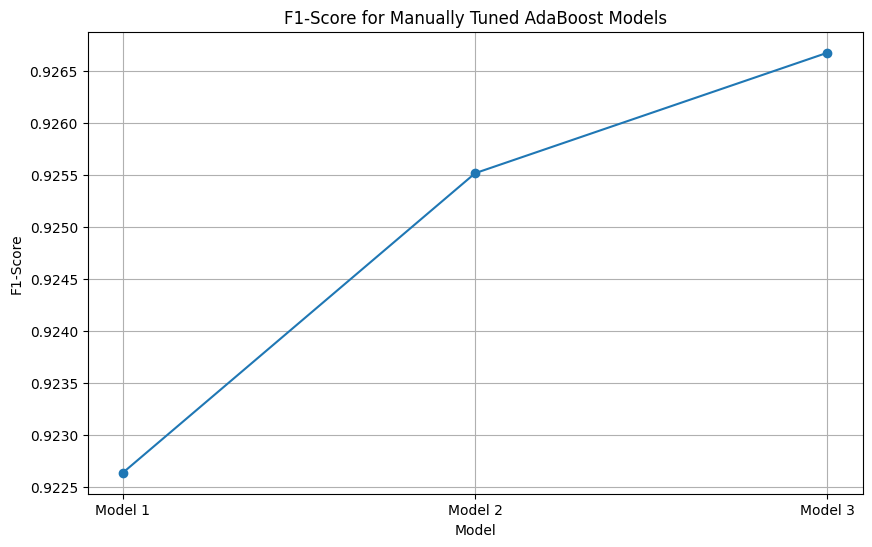

The best model is Model 3 with F1-score: 0.9266724429437861


In [10]:

plt.figure(figsize=(10, 6))
plt.plot(range(len(manual_scores)), manual_scores, marker='o')
plt.title('F1-Score for Manually Tuned AdaBoost Models')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(range(len(manual_scores)), [f"Model {i+1}" for i in range(len(manual_scores))])
plt.grid(True)
plt.show()

# Select the best model based on F1-score
best_model_index = manual_scores.index(max(manual_scores))
best_model = models[best_model_index]

print(f"The best model is Model {best_model_index + 1} with F1-score: {manual_scores[best_model_index]}")

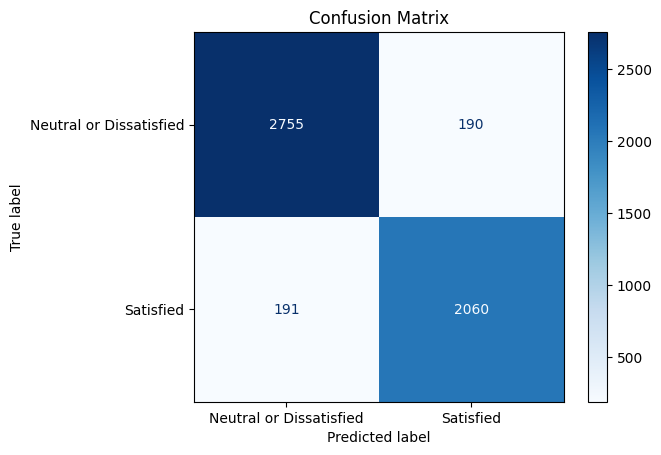

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

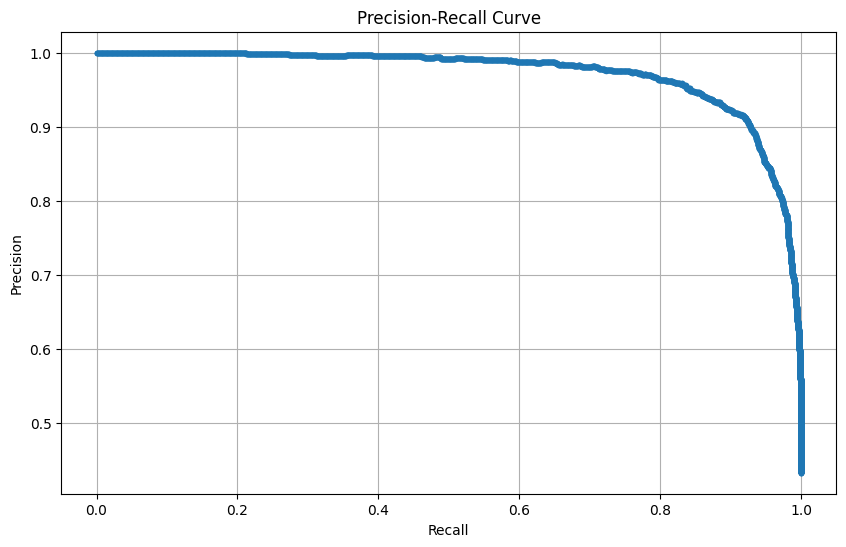

Precision-Recall AUC: 0.9716270632206101


In [14]:
# Assuming you have y_test and y_pred from your best model
y_scores = best_model.predict_proba(X_test_processed)[:, 1]  # Assuming binary classification

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

# Calculate AUC for Precision-Recall
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc}")

Precision-Recall AUC: 0.9716270632206101


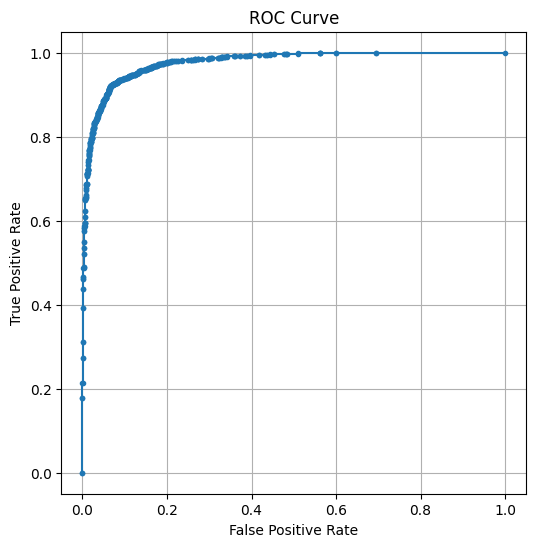

ROC AUC: 0.9770110850563304


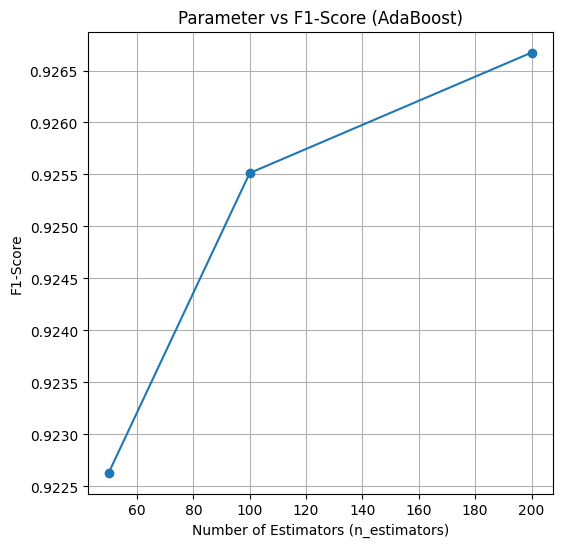

In [20]:

y_scores = best_model.decision_function(X_test_processed)


precision, recall, thresholds = precision_recall_curve(y_test, y_scores)


# Calculate AUC for Precision-Recall
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Plot the ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid(True)
plt.show()

# Calculate AUC for ROC
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc}")

# Generate a plot for parameter vs F1-Score
# Assume you have a list of parameter values and corresponding F1-scores
parameter_values = [param['n_estimators'] for param in manual_params]
f1_scores = manual_scores

plt.figure(figsize=(6, 6))
plt.plot(parameter_values, f1_scores, marker='o')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('F1-Score')
plt.title('Parameter vs F1-Score (AdaBoost)')
plt.grid(True)
plt.show()

In [18]:
manual_scores

[0.9226327944572749, 0.92551375635678, 0.9266724429437861]

**Conclusion:**
Starting from around 60 estimators with an F1-score close to 0.9225, the score gradually rises, reaching approximately 0.9265 with 200 estimators. This trend suggests that as more estimators are added, the AdaBoost model can better handle misclassifications, thereby boosting accuracy. The shape of the ROC curve suggests that the AdaBoost model effectively separates the classes, and a high area under the ROC curve (AUC) would imply strong discriminative power. This graph highlights the model’s robustness, showcasing its ability to correctly classify positive instances while minimizing false alarms.

**Future works:**
To improve the model, advanced hyperparameter tuning and cross-validation would make it more robust and adaptable to various datasets. Feature selection techniques, such as SHAP values or recursive feature elimination, can also help focus on the most relevant features, reducing complexity and enhancing performance. Additionally, experimenting with alternative ensemble models, like Gradient Boosting or XGBoost, could improve results. For interpretability, tools like SHAP or LIME could offer valuable insights into the model’s decision-making process, making it more accessible to stakeholders and aiding in transparent decision-making.